In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('../data/clean_data.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (2793, 77)
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Lot Shape Land Contour Utilities  ... Enclosed Porch 3Ssn Porch  \
0       IR1          Lvl    AllPub  ...              0          0   
1       Reg          Lvl    AllPub  ...              0          0   
2       IR1          Lvl    AllPub  ...              0          0   
3       Reg          Lvl    AllPub  ...              0          0   
4       IR1          Lvl    AllPub  ...              0          0   

  Screen Porch Pool Area Misc Val Mo Sold Yr Sold  Sale Type  Sale Condition  \
0            0         0

In [13]:
print("Columns:", df.columns.tolist())

Columns: ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch

In [14]:
# Feature Engineering

# Total area of house
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

# Age of house when sold
df['HouseAge'] = df['Yr Sold'] - df['Year Built']

# How long ago it was remodeled
df['RemodAge'] = df['Yr Sold'] - df['Year Remod/Add']

# Total bathrooms (half bath counts as 0.5)
df['TotalBath'] = (df['Full Bath'] + df['Half Bath'] * 0.5 +
                   df['Bsmt Full Bath'] + df['Bsmt Half Bath'] * 0.5)

# Total porch area
df['TotalPorch'] = (df['Open Porch SF'] + df['Enclosed Porch'] +
                    df['3Ssn Porch'] + df['Screen Porch'])

# Was it remodeled? 1 = yes, 0 = no
df['IsRemodeled'] = (df['Year Built'] != df['Year Remod/Add']).astype(int)

print("New features created!")
print(df[['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'TotalPorch', 'IsRemodeled']].head())

New features created!
   TotalSF  HouseAge  RemodAge  TotalBath  TotalPorch  IsRemodeled
0   2736.0        50        50        2.0          62            0
1   1778.0        49        49        1.0         120            0
2   2658.0        52        52        1.5          36            0
3   4220.0        42        42        3.5           0            0
4   2557.0        13        12        2.5          34            1


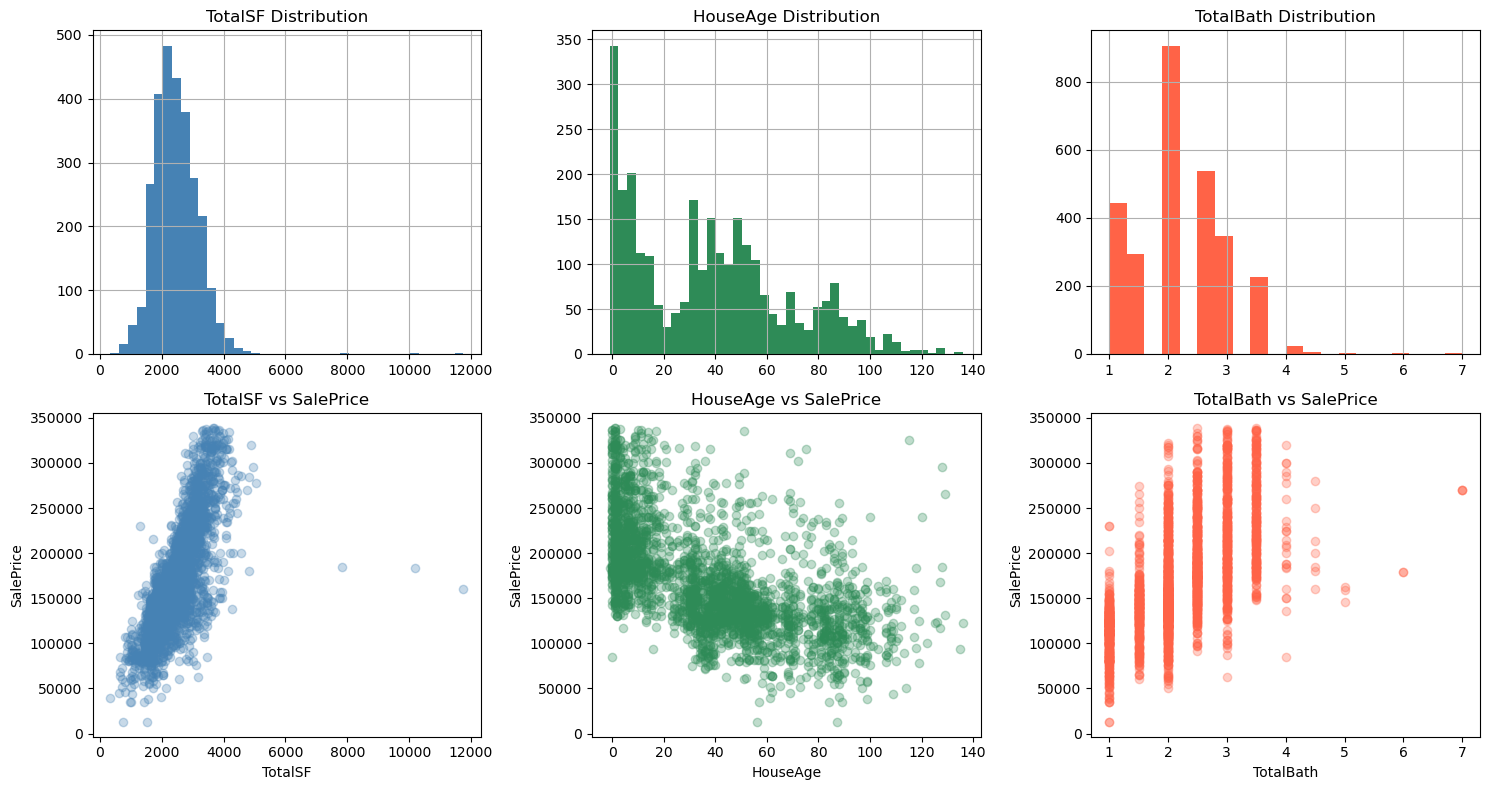

In [15]:
# Visualize new features

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

df['TotalSF'].hist(ax=axes[0,0], bins=40, color='steelblue')
axes[0,0].set_title('TotalSF Distribution')

df['HouseAge'].hist(ax=axes[0,1], bins=40, color='seagreen')
axes[0,1].set_title('HouseAge Distribution')

df['TotalBath'].hist(ax=axes[0,2], bins=20, color='tomato')
axes[0,2].set_title('TotalBath Distribution')

axes[1,0].scatter(df['TotalSF'], df['SalePrice'], alpha=0.3, color='steelblue')
axes[1,0].set_title('TotalSF vs SalePrice')
axes[1,0].set_xlabel('TotalSF')
axes[1,0].set_ylabel('SalePrice')

axes[1,1].scatter(df['HouseAge'], df['SalePrice'], alpha=0.3, color='seagreen')
axes[1,1].set_title('HouseAge vs SalePrice')
axes[1,1].set_xlabel('HouseAge')
axes[1,1].set_ylabel('SalePrice')

axes[1,2].scatter(df['TotalBath'], df['SalePrice'], alpha=0.3, color='tomato')
axes[1,2].set_title('TotalBath vs SalePrice')
axes[1,2].set_xlabel('TotalBath')
axes[1,2].set_ylabel('SalePrice')

plt.tight_layout()
plt.savefig('feature_engineering.png', dpi=150)
plt.show()

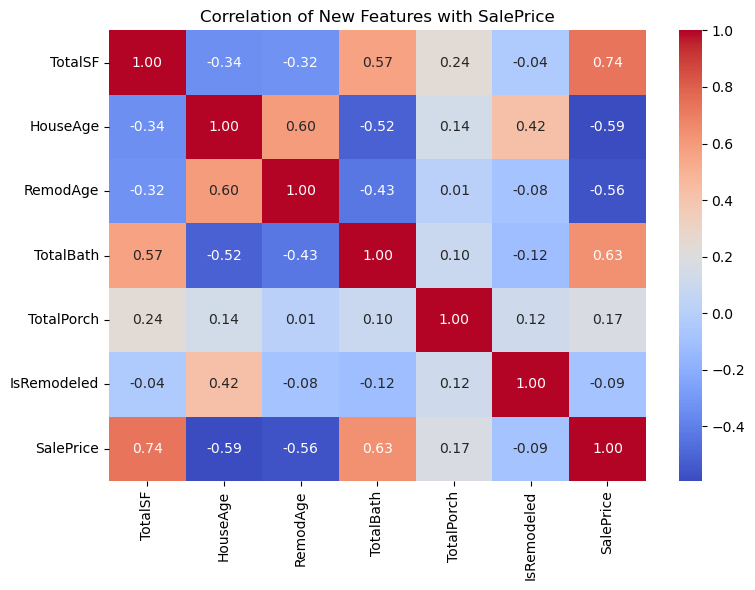

In [16]:
#  Correlation of new features with SalePrice

new_features = ['TotalSF', 'HouseAge', 'RemodAge', 
                'TotalBath', 'TotalPorch', 'IsRemodeled', 'SalePrice']

corr = df[new_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of New Features with SalePrice')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

In [17]:
# Encode categorical columns

cat_cols = df.select_dtypes(include='object').columns
print("Categorical columns to encode:", len(cat_cols))
print(cat_cols.tolist())

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("\nAfter encoding shape:", df.shape)

Categorical columns to encode: 38
['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']

After encoding shape: (2793, 255)


In [18]:
# Drop SalePrice_log if it accidentally exists
df = df.drop(['SalePrice_log'], axis=1, errors='ignore')

# Final check
if 'SalePrice_log' in df.columns:
    print("WARNING: SalePrice_log still present — remove it!")
else:
    print("Good! SalePrice_log is not in the data.")

print("SalePrice present:", 'SalePrice' in df.columns)
print("Final shape:", df.shape)

# Save
df.to_csv('prepared_data.csv', index=False)
print("\nprepared_data.csv saved successfully!")

Good! SalePrice_log is not in the data.
SalePrice present: True
Final shape: (2793, 255)

prepared_data.csv saved successfully!
